In [6]:
# import pandas as pd
# import pickle

# with open("Data_results/Bond_0.75/optimizer_result.pkl", "rb") as f:
#     results_75 = pickle.load(f)

# parameters_75 = results_75.x
# parameters_initial = [0.05928074, 0.07256101, -0.08495465]

# import pandas as pd

initial_parameters = {
    0.60: [0.05424044, 0.06461556, -0.09721599],
    0.70: [0.0821556, 0.03705277, -0.11171107],
    0.80: [0.07263012, 0.08563716, -0.03860591],
    0.90: [0.0735935, -0.06038758, -0.10268653]
}

# initial_parameters = pd.DataFrame(initial_parameters)
# print(initial_parameters)

In [7]:
from qiskit_ibm_runtime import QiskitRuntimeService, Estimator

service = QiskitRuntimeService(name="TJ")
service.active_account()
print('Available backends:')
print(service.backends(simulator=False))



qiskit_runtime_service.__init__:WARNING:2026-05-09 10:25:17,230: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-09 10:25:17,232: Loading instance: open-instance, plan: open


Available backends:
[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_marrakesh')>, <IBMBackend('ibm_kingston')>]


In [8]:
# backend = service.least_busy(operational=True, simulator=False)
backend = service.backend("ibm_fez")
print(f"Backend = {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-05-09 10:25:18,717: Using instance: open-instance, plan: open


Backend = ibm_fez


## For Compiling on QPU


In [9]:
# estimator = Estimator(mode=backend)       
# estimator.options.default_shots = 1024

## Local Compilation

In [10]:
# We will start by using a local simulator
from qiskit_aer import AerSimulator

# Import an estimator, this time from qiskit (we will import from Runtime for real hardware)
from qiskit.primitives import BackendEstimatorV2

# generate a simulator that mimics the real quantum system
backend_sim = AerSimulator.from_backend(backend)
# estimator = BackendEstimatorV2(backend=backend_sim)

from qiskit_ibm_runtime import EstimatorV2, Estimator
from qiskit_ibm_runtime.options import EstimatorOptions

options = EstimatorOptions()

# Set top-level attributes
options.default_shots = 1024
options.resilience_level = 2  # Turns on Zero Noise Extrapolation (ZNE)

# Access nested configurations for advanced resilience/twirling
options.resilience.zne_mitigation = True
options.twirling.enable_gates = True

estimatorv2 = EstimatorV2(mode=backend_sim, options=options)
estimatorv1 = Estimator(mode=backend_sim)    
# Level 2 turns on Zero Noise Extrapolation (ZNE) automatically
# Level 3 forces the cloud to transpile, optimize, and apply Dynamical Decoupling natively



In [11]:
import numpy as np
import pandas as pd

from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit



from qiskit_nature.second_q.mappers import JordanWignerMapper
mapper = JordanWignerMapper()

from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

num_spatial_orbitals = 2
num_particles = (1, 1)
ansatz = UCCSD(
    num_spatial_orbitals,
    num_particles,
    mapper,
    initial_state=HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    ),
)
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from scipy.optimize import minimize

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
ansatz_isa = pm.run(ansatz)

from time import time


energies = []
ground_energies = []
optimizer_times = []
iteration_number = []
optimizer_results = []
nuclear_repulsion_energies = []
energy_histories = []
optimal_parameters_list = []


# Bond lengths in Angstrom
bond_lengths = np.arange(0.30, 1.50, 0.05) 


for r in bond_lengths:
    # Define H2 geometry
    geometry = f"H 0 0 0; H 0 0 {r}"

    # PySCF driver
    driver = PySCFDriver(
        atom=geometry,
        basis="sto3g",
        spin=0,
        charge=0,
        unit=DistanceUnit.ANGSTROM,
    )

    # Run electronic structure calculation
    problem = driver.run()
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy


    #print(f"Running VQE for bond length {r} Å with initial parameters: {initial_parameters[r]}")
    vqe_solver = VQE(estimatorv1, ansatz, COBYLA())
    vqe_solver.initial_point = initial_parameters[0.70]       # IMPORTANT
    x0 = vqe_solver.initial_point

    solver = GroundStateEigensolver(mapper, vqe_solver)

    main_operator, aux_ops = solver.get_qubit_operators(problem)

    H = main_operator
    hamiltonian_isa = H.apply_layout(ansatz_isa.layout)

    energy_history = []

    def cost_func(params, ansatz, H, estimator):
        pub = (ansatz, H, params)
        result = estimator.run(pubs=[pub]).result()
        energy = result[0].data.evs
        energy_history.append(energy)  
        return energy

    start_time = time()
    result = minimize(
        cost_func,
        x0,
        args=(ansatz_isa, hamiltonian_isa, estimatorv2),
        method="cobyla",
        options={"maxiter": 15, "disp": True},)

    optimizer_time = time() - start_time
    energy = result.fun
    optimal_parameters = result.x
    ground_state_energy = energy + nuclear_repulsion
    print(f"Ground state energy for bond length {r} Å: {ground_state_energy:.6f} Hartree")


    energies.append(energy)
    ground_energies.append(ground_state_energy)
    optimizer_results.append(result)
    optimizer_times.append(optimizer_time)
    nuclear_repulsion_energies.append(nuclear_repulsion)
    iteration_number.append(result.nfev)
    energy_histories.append(energy_history)
    optimal_parameters_list.append(optimal_parameters)





/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'resilience': {'zne_mitigation': True}, 'twirling': {'enable_gates': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.1120076564960257
The corresponding X is:
[ 0.13292042  0.01048394 -0.03191624]

Ground state energy for bond length 0.3 Å: -0.348084 Hartree


/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'resilience': {'zne_mitigation': True}, 'twirling': {'enable_gates': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -2.101195551758977
The corresponding X is:
[ 0.0821556   0.03705277 -0.11171107]

Ground state energy for bond length 0.35 Å: -0.589261 Hartree


/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'resilience': {'zne_mitigation': True}, 'twirling': {'enable_gates': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit

...

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.3421109922387957
The corresponding X is:
[-0.07247779 -0.09080857 -0.20425875]

Ground state energy for bond length 1.3499999999999999 Å: -0.950128 Hartree


/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'resilience': {'zne_mitigation': True}, 'twirling': {'enable_gates': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.3126851793815795
The corresponding X is:
[-0.05745936 -0.09204198 -0.29845501]

Ground state energy for bond length 1.3999999999999997 Å: -0.934701 Hartree


/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:274: UserWarning: Options {'resilience': {'zne_mitigation': True}, 'twirling': {'enable_gates': True}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:190: UserWarning: The resilience_level option has no effect in local testing mode.
  warnings.warn("The resilience_level option has no effect in local testing mode.")
/home/takshit/miniconda3/envs/qiskit-1.4.5/lib/python3.12/site-packages/qiskit

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 15   Least value of F = -1.3052222713623838
The corresponding X is:
[-0.00516739 -0.05362261 -0.40499883]

Ground state energy for bond length 1.4499999999999997 Å: -0.940272 Hartree


In [12]:

# Create table
df = pd.DataFrame({
    "Bond Length": bond_lengths,
    "Results": optimizer_results,
    "Ground State Energy (Hartree)": ground_energies,
    "Time (s)": optimizer_times,
    "Nuclear Repulsion Energy (Hartree)": nuclear_repulsion_energies,
    "Electronic Energies (Hartree)": energies,
    "Convergence History": energy_histories,
    "optimal_parameters_list": optimal_parameters_list
})
print(df)

    Bond Length                                            Results  \
0          0.30  {'x': [0.13292041917793665, 0.0104839424729026...   
1          0.35  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
2          0.40  {'x': [-0.03176677245785152, 0.047284373258894...   
3          0.45  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
4          0.50  {'x': [0.10531998348603794, 0.0795998209235446...   
5          0.55  {'x': [0.055369940939803325, 0.043279191031822...   
6          0.60  {'x': [0.07590333488773336, 0.0294848664524061...   
7          0.65  {'x': [0.08229712010359413, 0.0320764396543496...   
8          0.70  {'x': [0.08445300542816747, 0.0391576624010640...   
9          0.75  {'x': [0.14401946229430354, 0.1156414966772600...   
10         0.80  {'x': [-0.014650297771910917, 0.02228393687227...   
11         0.85  {'x': [0.0821556, 0.03705277, -0.11171107], 's...   
12         0.90  {'x': [0.012236417437067701, -0.00518666124759...   
13         0.95  {'x

In [13]:
# df.to_pickle("dataframe.pkl")
# df = pd.read_pickle("dataframe.pkl")

# import pickle
# location = "Data_results/Aer_Simulator_Results/Aer_Results_2.pkl"
# df.to_pickle(location)

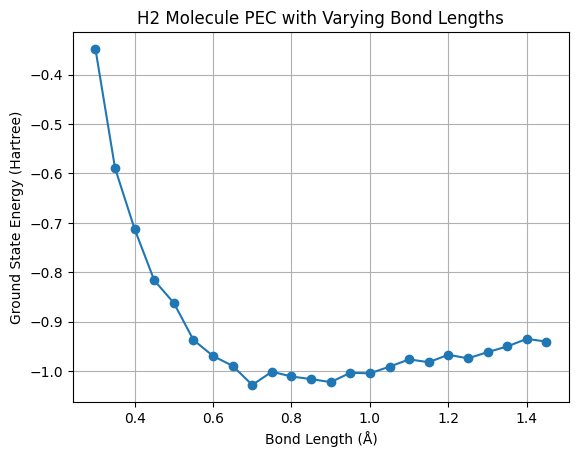

In [14]:
from matplotlib import pyplot as plt

plt.plot(bond_lengths, ground_energies, marker='o')
plt.grid(True)
plt.xlabel("Bond Length (Å)")
plt.ylabel("Ground State Energy (Hartree)")
plt.title("H2 Molecule PEC with Varying Bond Lengths")
plt.show()

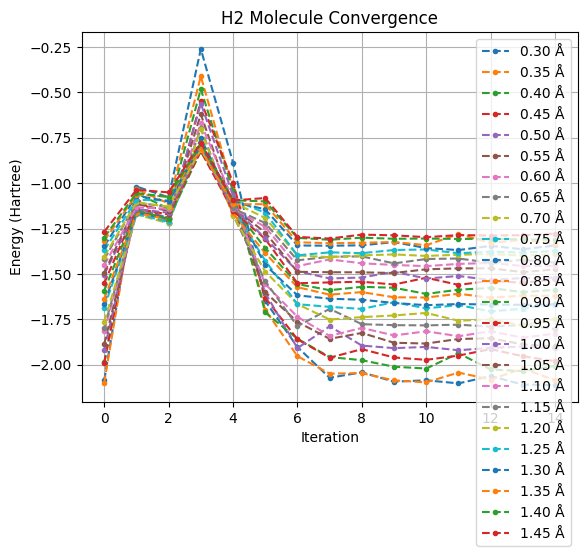

In [15]:
for history in energy_histories:
    plt.plot(history, marker='.', linestyle='--')
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("Energy (Hartree)")
plt.title("H2 Molecule Convergence")
plt.legend([f"{r:.2f} Å" for r in bond_lengths])
plt.show()

ansatz depth = 317


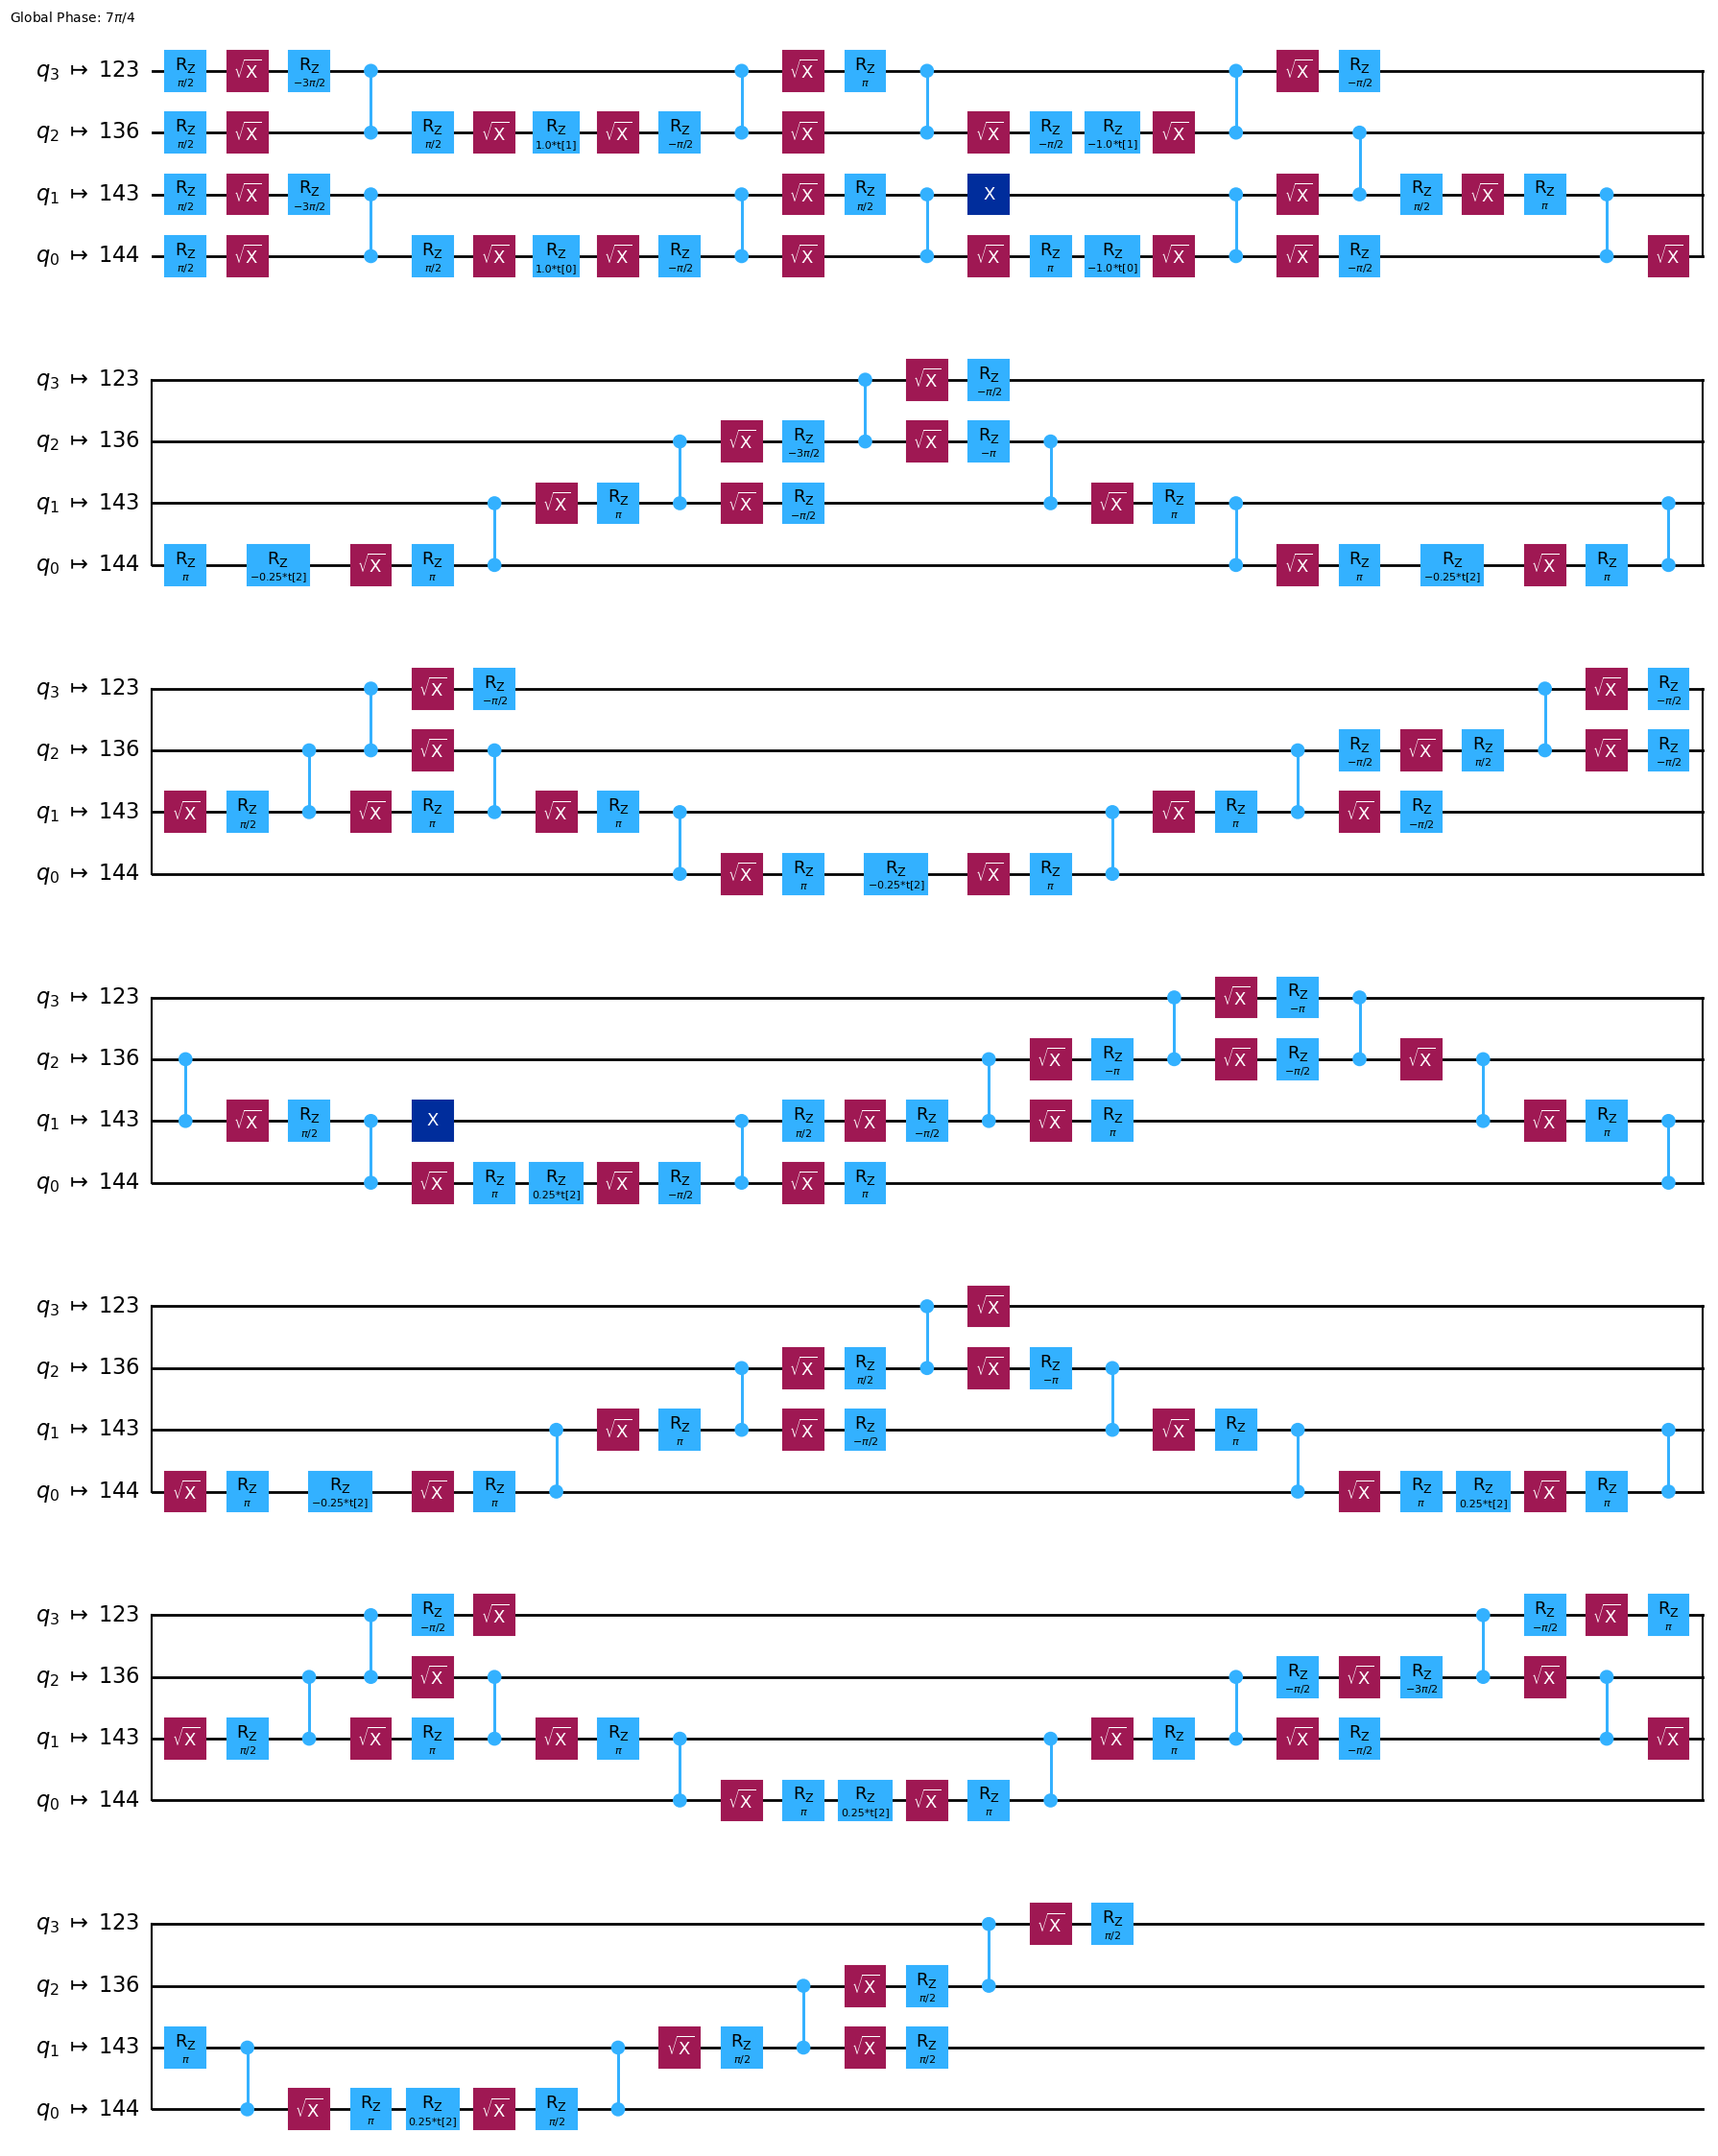

In [16]:
print(f"ansatz depth = {ansatz_isa.decompose().depth()}")
ansatz_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [17]:
df.head(7)

,Bond Length,Results,Ground State Energy (Hartree),Time (s),Nuclear Repulsion Energy (Hartree),Electronic Energies (Hartree),Convergence History,optimal_parameters_list
0,0.30,"{'x': [0.13292041917793665, 0.0104839424729026...",-0.348084,167.878811,1.763924,-2.112008,"[-2.0866897707080687, -1.0187247491783715, -1....","[0.13292041917793665, 0.010483942472902623, -0..."
1,0.35,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.589261,158.549716,1.511935,-2.101196,"[-2.101195551758977, -1.0334780242680757, -1.1...","[0.0821556, 0.03705277, -0.11171107]"
2,0.40,"{'x': [-0.03176677245785152, 0.047284373258894...",-0.712678,121.986768,1.322943,-2.035621,"[-1.9877964886882793, -1.0552686518381127, -1....","[-0.03176677245785152, 0.047284373258894195, -..."
3,0.45,"{'x': [0.0821556, 0.03705277, -0.11171107], 's...",-0.816325,116.177677,1.175949,-1.992275,"[-1.9922746350736713, -1.085103998637592, -1.2...","[0.0821556, 0.03705277, -0.11171107]"
4,0.50,"{'x': [0.10531998348603794, 0.0795998209235446...",-0.862165,111.752108,1.058354,-1.920519,"[-1.9192007300764726, -1.1405158909466595, -1....","[0.10531998348603794, 0.07959982092354465, -0...."
5,0.55,"{'x': [0.055369940939803325, 0.043279191031822...",-0.937018,158.523191,0.962140,-1.899158,"[-1.8875637205894253, -1.1577730319998336, -1....","[0.055369940939803325, 0.04327919103182291, -0..."
6,0.60,"{'x': [0.07590333488773336, 0.0294848664524061...",-0.969379,122.286240,0.881962,-1.851341,"[-1.8171013844412056, -1.1719728449317115, -1....","[0.07590333488773336, 0.02948486645240618, -0...."


In [13]:
# # Saving Data
# import os
# import pickle
# import json
# from qiskit import qpy
# from google.colab import drive

# # Mount Google Drive (safe if already mounted)
# drive.mount('/content/drive')

# save_dir = "/content/drive/MyDrive/vqe_experiment"
# os.makedirs(save_dir, exist_ok=True)

# # -----------------------------
# # 1. Save optimizer result
# # -----------------------------
# with open(os.path.join(save_dir, "optimizer_result.pkl"), "wb") as f:
#     pickle.dump(result, f)

# # -----------------------------
# # 2. Save optimized parameters
# # -----------------------------
# optimal_parameters = result.x
# with open(os.path.join(save_dir, "optimal_parameters.pkl"), "wb") as f:
#     pickle.dump(optimal_parameters, f)

# # -----------------------------
# # 3. Save Hamiltonian
# # -----------------------------
# with open(os.path.join(save_dir, "hamiltonian.pkl"), "wb") as f:
#     pickle.dump(hamiltonian_isa, f)

# # -----------------------------
# # 4. Save Ansatz Circuit
# # -----------------------------
# with open(os.path.join(save_dir, "ansatz.qpy"), "wb") as f:
#     qpy.dump(ansatz_isa, f)

# # -----------------------------
# # 5. Save backend information
# # -----------------------------
# backend_info = {
#     "backend_name": backend.name,
#     "num_qubits": backend.num_qubits,
#     "version": backend.version,
# }

# with open(os.path.join(save_dir, "backend_info.json"), "w") as f:
#     json.dump(backend_info, f, indent=4)

# # -----------------------------
# # 6. Save experiment metadata
# # -----------------------------
# experiment_metadata = {
#     "bond_length": float(r),
#     "basis": "sto3g",
#     "shots": estimator.options.default_shots,
#     "optimizer": "COBYLA",
#     "maxiter": 40,
#     "energy": float(energy),
#     "ground_state_energy": float(ground_state_energy),
#     "nuclear_repulsion_energy": float(nuclear_repulsion),
#     "iterations": result.nfev,
#     "optimizer_success": result.success,
#     "backend": backend.name
# }

# with open(os.path.join(save_dir, "experiment_metadata.json"), "w") as f:
#     json.dump(experiment_metadata, f, indent=4)

# # -----------------------------
# # 7. Save DataFrame results
# # -----------------------------
# df.to_pickle(os.path.join(save_dir, "results_dataframe.pkl"))
# df.to_csv(os.path.join(save_dir, "results_dataframe.csv"), index=False)

# # -----------------------------
# # 8. Save additional circuit info
# # -----------------------------
# circuit_info = {
#     "num_qubits": ansatz_isa.num_qubits,
#     "num_parameters": ansatz_isa.num_parameters,
#     "circuit_depth": ansatz_isa.depth()
# }

# with open(os.path.join(save_dir, "circuit_info.json"), "w") as f:
#     json.dump(circuit_info, f, indent=4)

# print("✅ All VQE experiment data saved in:")
# print(save_dir)

# # Optional: list files saved
# print("\nSaved files:")
# print(os.listdir(save_dir))